# Brain Tumor MRI Classification (Part-3)

**NAME      : KODANDA CHALLA**

**STUDENT ID: 25727**

***Multiclass image classification (4-class)***

## Project Overview
This project implements a deep learning pipeline to classify brain tumors from MRI images into four categories:
- **Glioma**: A type of brain tumor that starts in the brain
- **Meningioma**: A tumor of the membrane surrounding the brain
- **No Tumor**: Normal, healthy brain tissue
- **Pituitary**: Tumors in the pituitary gland

**Approach**: Transfer learning using ResNet50 pre-trained on ImageNet for feature extraction.

---

## 1. Import Libraries and Set Configurations

In [1]:
# Standard libraries
import os
import cv2
import time
import random
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Deep Learning
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Explainability
from lime import lime_image
from skimage.segmentation import mark_boundaries

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU Available: []


## 2. Set Random Seeds for Reproducibility

In [2]:
# Configuration Constants
DATASET_PATH = "Dataset_MRI"
TRAIN_DIR = os.path.join(DATASET_PATH, 'Training')
TEST_DIR = os.path.join(DATASET_PATH, 'Testing')
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE_DL = 224  # ResNet50 expects 224x224 images
SEED = 42
BATCH_SIZE = 32
EPOCHS = 15
VALIDATION_SPLIT = 0.35

# Set random seeds for reproducibility
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Dataset Path: {DATASET_PATH}")
print(f"Classes: {CLASSES}")
print(f"Image Size: {IMG_SIZE_DL}x{IMG_SIZE_DL}")

Dataset Path: Dataset_MRI
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Image Size: 224x224


## 3. Load and Prepare Dataset

In [3]:
def build_dataframe(data_dir, classes):
    """
    Build a DataFrame containing file paths and labels for all images in the dataset.
    
    Args:
        data_dir (str): Path to the data directory
        classes (list): List of class names
    
    Returns:
        pd.DataFrame: DataFrame with 'filepath' and 'label' columns
    """
    rows = []
    for label in classes:
        class_dir = os.path.join(data_dir, label)
        if not os.path.exists(class_dir):
            print(f"Warning: Directory {class_dir} not found!")
            continue
        
        for fname in os.listdir(class_dir):
            if fname.endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff')):
                rows.append({
                    'filepath': os.path.join(class_dir, fname),
                    'label': label
                })
    
    return pd.DataFrame(rows)

# Build datasets
train_df = build_dataframe(TRAIN_DIR, CLASSES)
test_df = build_dataframe(TEST_DIR, CLASSES)

print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print(f"\nClass distribution (Train):")
print(train_df['label'].value_counts())
print(f"\nSample training data:")
display(train_df.sample(5))

Train dataset shape: (5600, 2)
Test dataset shape: (1600, 2)

Class distribution (Train):
label
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

Sample training data:


,filepath,label
4795,Dataset_MRI\Training\pituitary\Tr-pi_274.jpg,pituitary
4269,Dataset_MRI\Training\pituitary\Tr-pi_1060.jpg,pituitary
2004,Dataset_MRI\Training\meningioma\Tr-me_282.jpg,meningioma
2515,Dataset_MRI\Training\meningioma\Tr-me_742.jpg,meningioma
3014,Dataset_MRI\Training\notumor\Tr-no_1191.jpg,notumor


## 4. Data Loading and Preprocessing

In [4]:
def load_images(df, img_size=224, preprocess_fn=None):
    """
    Load and preprocess images from file paths.
    
    Args:
        df (pd.DataFrame): DataFrame with 'filepath' and 'label' columns
        img_size (int): Target image size (height and width)
        preprocess_fn (callable, optional): Preprocessing function (e.g., ResNet50 preprocess_input)
    
    Returns:
        tuple: (images array, labels array)
    """
    images, labels = [], []
    failed_images = []

    for idx, (_, row) in enumerate(df.iterrows()):
        try:
            img = cv2.imread(row['filepath'], cv2.IMREAD_UNCHANGED)

            if img is None:
                failed_images.append(row['filepath'])
                continue

            # Handle different image formats
            if len(img.shape) == 2:  # Grayscale
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif img.shape[2] == 4:  # RGBA/BGRA
                img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
            elif img.shape[2] == 3:  # BGR (OpenCV default)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize to target size
            img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
            img = img.astype('float32')

            # Apply preprocessing function if provided
            if preprocess_fn is not None:
                img = preprocess_fn(img)
            else:
                img = img / 255.0  # Normalize to [0, 1]

            images.append(img)
            labels.append(row['label'])
        
        except Exception as e:
            print(f"Error loading {row['filepath']}: {e}")
            failed_images.append(row['filepath'])

    if failed_images:
        print(f"\nWarning: Failed to load {len(failed_images)} images")

    return np.array(images), np.array(labels)

# Load training data with ResNet50 preprocessing
print("Loading training data...")
X_train, y_train_raw = load_images(train_df, IMG_SIZE_DL, preprocess_fn=preprocess_input)
print(f"Training data shape: {X_train.shape}")

print("\nLoading test data...")
X_test, y_test_raw = load_images(test_df, IMG_SIZE_DL, preprocess_fn=preprocess_input)
print(f"Test data shape: {X_test.shape}")

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

# Convert to categorical for neural network
y_train_cat = to_categorical(y_train, num_classes=len(CLASSES))
y_test_cat = to_categorical(y_test, num_classes=len(CLASSES))

print(f"\nLabel mapping: {dict(zip(le.classes_, range(len(CLASSES))))}")

Loading training data...
Training data shape: (5600, 224, 224, 3)

Loading test data...
Test data shape: (1600, 224, 224, 3)

Label mapping: {np.str_('glioma'): 0, np.str_('meningioma'): 1, np.str_('notumor'): 2, np.str_('pituitary'): 3}


## 5. Build ResNet50 Transfer Learning Model

In [5]:
def build_resnet50_model(num_classes=4, freeze_base=True):
    """
    Build a ResNet50 transfer learning model.
    
    Args:
        num_classes (int): Number of output classes
        freeze_base (bool): Whether to freeze base model weights
    
    Returns:
        Model: Compiled Keras model
    """
    # Load pre-trained ResNet50
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_DL, IMG_SIZE_DL, 3)
    )
    
    # Freeze base model weights
    base_model.trainable = freeze_base
    
    # Add custom layers
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    
    return model

# Build model
model = build_resnet50_model(num_classes=len(CLASSES), freeze_base=True)

# Display model architecture
print("Model Architecture:")
model.summary()

Model Architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,772,228 (94.50 MB)

 Trainable params: 24,717,572 (94.29 MB)

 Non-trainable params: 54,656 (213.50 KB)

## 6. Train the Model

In [6]:
# Define callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

# Train the model
print("Starting training...\n")
start_time = time.time()

history = model.fit(
    X_train, y_train_cat,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Starting training...

Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7550 - loss: 0.7582 - precision: 0.7685 - recall: 0.7323

114/114 ━━━━━━━━━━━━━━━━━━━━ 795s 7s/step - accuracy: 0.8245 - loss: 0.5496 - precision: 0.8342 - recall: 0.8115 - val_accuracy: 0.2857 - val_loss: 22.6752 - val_precision: 0.2857 - val_recall: 0.2857 - learning_rate: 0.0010
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 745s 7s/step - accuracy: 0.9154 - loss: 0.2391 - precision: 0.9195 - recall: 0.9102 - val_accuracy: 0.2046 - val_loss: 3.9860 - val_precision: 0.2043 - val_recall: 0.2036 - learning_rate: 0.0010
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 744s 7s/step - accuracy: 0.9599 - loss: 0.1235 - precision: 0.9609 - recall: 0.9588 - val_accuracy: 0.2832 - val_loss: 3.8320 - val_precision: 0.2845 - val_recall: 0.2832 - learning_rate: 0.0010
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 746s 7s/step - accuracy: 0.9764 - loss: 0.0771 - precision: 0.9772 - recall: 0.9755 - val_accuracy: 0.2811 - val_loss: 4.7981 - val_precision: 0.2826 - val_recall: 0.2811 - learning_rate: 0.0010
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9683 

## 7. Plot Training History

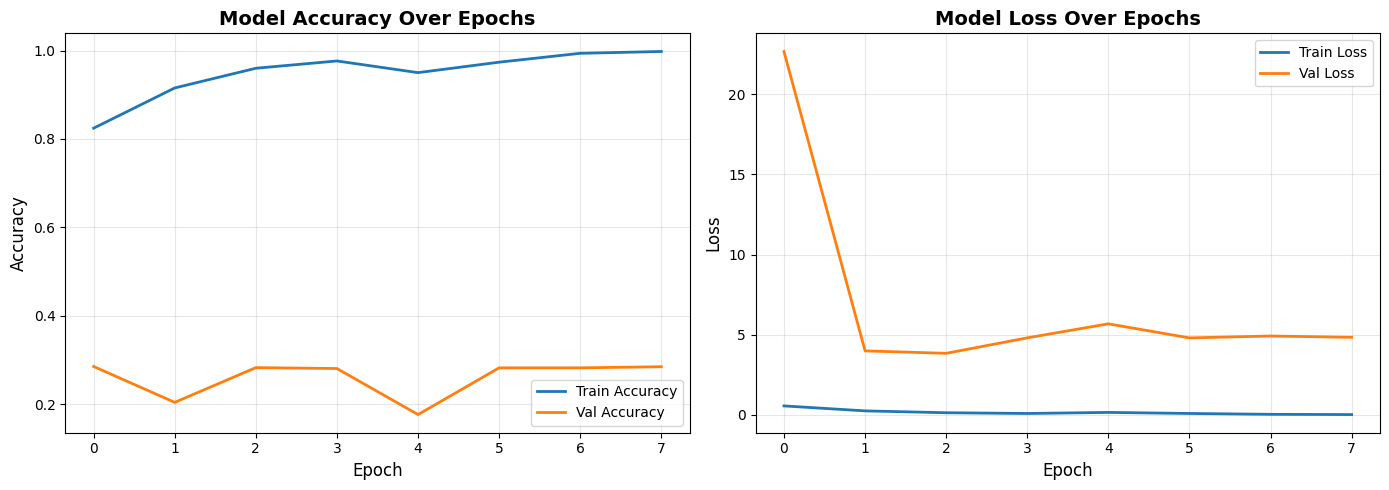

Final Training Accuracy: 0.9978
Final Validation Accuracy: 0.2852


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 8. Model Evaluation on Test Set

In [8]:
# Make predictions
print("Evaluating model on test set...\n")
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision (weighted): {test_precision:.4f}")
print(f"Test Recall (weighted): {test_recall:.4f}")
print(f"Test F1-Score (weighted): {test_f1:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

Evaluating model on test set...

Test Accuracy: 0.5869
Test Precision (weighted): 0.5258
Test Recall (weighted): 0.5869
Test F1-Score (weighted): 0.4936

Detailed Classification Report:
              precision    recall  f1-score   support

      glioma     1.0000    0.4000    0.5714       400
  meningioma     0.4699    0.9550    0.6298       400
     notumor     0.6332    0.9925    0.7731       400
   pituitary     0.0000    0.0000    0.0000       400

    accuracy                         0.5869      1600
   macro avg     0.5258    0.5869    0.4936      1600
weighted avg     0.5258    0.5869    0.4936      1600



## 9. Confusion Matrix Visualization

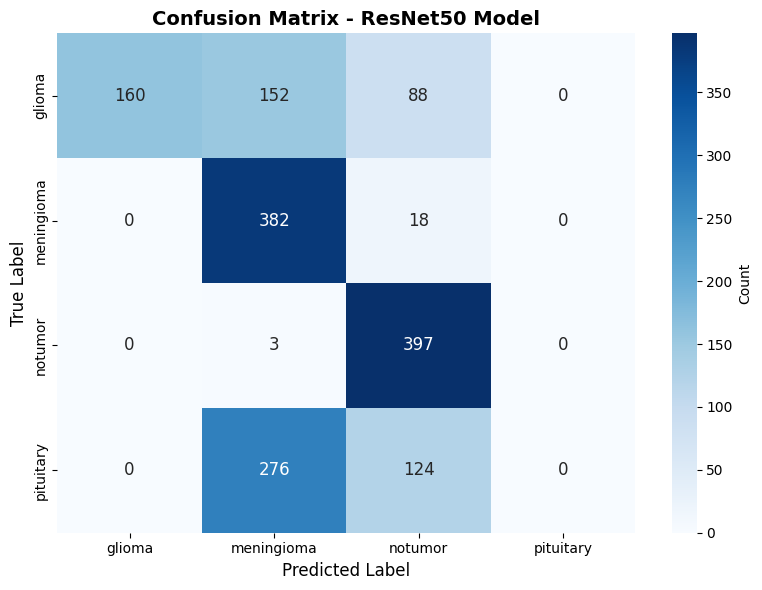


Per-Class Accuracy:
glioma: 0.4000
meningioma: 0.9550
notumor: 0.9925
pituitary: 0.0000


In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    cbar_kws={'label': 'Count'}, annot_kws={'fontsize': 12}
)
plt.title('Confusion Matrix - ResNet50 Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
for i, class_name in enumerate(le.classes_):
    class_accuracy = cm[i, i] / cm[i].sum()
    print(f"{class_name}: {class_accuracy:.4f}")

## 10. Model Trustworthiness Assessment

**Trustworthiness** measures how reliable and dependable the model's predictions are. We assess this through multiple dimensions:

In [10]:
def calculate_trustworthiness_metrics(y_true, y_pred, y_pred_probs, class_names):
    """
    Calculate trustworthiness metrics for model evaluation.
    
    Trustworthiness dimensions:
    1. Confidence: How confident is the model in its predictions?
    2. Calibration: Are confidence scores aligned with actual accuracy?
    3. Consistency: Are predictions stable across similar examples?
    4. Reliability: How well does the model perform on each class?
    """
    
    metrics = {}
    
    # 1. Average Confidence Score
    max_probs = np.max(y_pred_probs, axis=1)
    avg_confidence = np.mean(max_probs)
    metrics['avg_confidence'] = avg_confidence
    
    # 2. Prediction Entropy (lower = more confident)
    epsilon = 1e-10
    entropy = -np.sum(y_pred_probs * np.log(y_pred_probs + epsilon), axis=1)
    avg_entropy = np.mean(entropy)
    metrics['avg_entropy'] = avg_entropy
    
    # 3. Confidence-Accuracy Calibration
    correct_mask = (y_true == y_pred)
    correct_confidence = max_probs[correct_mask].mean() if correct_mask.sum() > 0 else 0
    incorrect_confidence = max_probs[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0
    metrics['correct_avg_confidence'] = correct_confidence
    metrics['incorrect_avg_confidence'] = incorrect_confidence
    metrics['confidence_gap'] = correct_confidence - incorrect_confidence
    
    # 4. Class-wise Reliability
    class_reliability = {}
    for i, class_name in enumerate(class_names):
        mask = y_true == i
        if mask.sum() > 0:
            class_acc = (y_pred[mask] == y_true[mask]).mean()
            class_confidence = max_probs[mask].mean()
            class_reliability[class_name] = {
                'accuracy': class_acc,
                'avg_confidence': class_confidence,
                'samples': mask.sum()
            }
    metrics['class_reliability'] = class_reliability
    
    # 5. Overall Trustworthiness Score (0-100)
    # Components:
    # - Overall accuracy (40%)
    # - Confidence-Accuracy alignment (30%)
    # - Confidence level (20%)
    # - Low entropy (10%)
    
    overall_accuracy = accuracy_score(y_true, y_pred)
    calibration_score = min(1.0, metrics['confidence_gap'] / 0.5)  # Normalized
    confidence_score = min(1.0, avg_confidence / 0.95)  # Normalized
    entropy_score = max(0, 1.0 - (avg_entropy / 1.4))  # Normalized (max entropy for 4 classes ≈ 1.386)
    
    trustworthiness_score = (
        0.40 * overall_accuracy +
        0.30 * calibration_score +
        0.20 * confidence_score +
        0.10 * entropy_score
    ) * 100
    
    metrics['overall_trustworthiness_score'] = trustworthiness_score
    
    return metrics

# Calculate trustworthiness
trustworthiness = calculate_trustworthiness_metrics(y_test, y_pred, y_pred_probs, le.classes_)

print("="*70)
print("MODEL TRUSTWORTHINESS ASSESSMENT")
print("="*70)
print(f"\n📊 Overall Trustworthiness Score: {trustworthiness['overall_trustworthiness_score']:.2f}/100")
print(f"\n🎯 Key Metrics:")
print(f"   • Average Confidence: {trustworthiness['avg_confidence']:.4f}")
print(f"   • Prediction Entropy (lower is better): {trustworthiness['avg_entropy']:.4f}")
print(f"   • Correct Predictions Confidence: {trustworthiness['correct_avg_confidence']:.4f}")
print(f"   • Incorrect Predictions Confidence: {trustworthiness['incorrect_avg_confidence']:.4f}")
print(f"   • Confidence-Accuracy Gap: {trustworthiness['confidence_gap']:.4f}")
print(f"     (Higher gap indicates better calibration)")

print(f"\n📈 Class-wise Reliability:")
for class_name, metrics_dict in trustworthiness['class_reliability'].items():
    print(f"\n   {class_name.upper()}:")
    print(f"      - Accuracy: {metrics_dict['accuracy']:.4f}")
    print(f"      - Avg Confidence: {metrics_dict['avg_confidence']:.4f}")
    print(f"      - Test Samples: {metrics_dict['samples']}")

print(f"\n\n✅ Trustworthiness Interpretation:")
if trustworthiness['overall_trustworthiness_score'] >= 85:
    print("   🟢 HIGHLY TRUSTWORTHY: The model is reliable for deployment.")
elif trustworthiness['overall_trustworthiness_score'] >= 75:
    print("   🟡 MODERATELY TRUSTWORTHY: Good for most applications with monitoring.")
elif trustworthiness['overall_trustworthiness_score'] >= 65:
    print("   🟠 FAIRLY TRUSTWORTHY: Requires careful use and validation on new data.")
else:
    print("   🔴 LOW TRUSTWORTHINESS: Needs improvement before deployment.")

print("\n" + "="*70)

MODEL TRUSTWORTHINESS ASSESSMENT

📊 Overall Trustworthiness Score: 58.16/100

🎯 Key Metrics:
   • Average Confidence: 0.9220
   • Prediction Entropy (lower is better): 0.2015
   • Correct Predictions Confidence: 0.9682
   • Incorrect Predictions Confidence: 0.8564
   • Confidence-Accuracy Gap: 0.1118
     (Higher gap indicates better calibration)

📈 Class-wise Reliability:

   GLIOMA:
      - Accuracy: 0.4000
      - Avg Confidence: 0.8561
      - Test Samples: 400

   MENINGIOMA:
      - Accuracy: 0.9550
      - Avg Confidence: 0.9693
      - Test Samples: 400

   NOTUMOR:
      - Accuracy: 0.9925
      - Avg Confidence: 0.9987
      - Test Samples: 400

   PITUITARY:
      - Accuracy: 0.0000
      - Avg Confidence: 0.8639
      - Test Samples: 400


✅ Trustworthiness Interpretation:
   🔴 LOW TRUSTWORTHINESS: Needs improvement before deployment.



## 11. Model Explainability with LIME

Image Index: 0
True Class: glioma
Predicted Class: meningioma
Prediction Confidence: 0.9965

Generating LIME explanation (this may take a moment)...


  0%|          | 0/500 [00:00<?, ?it/s]

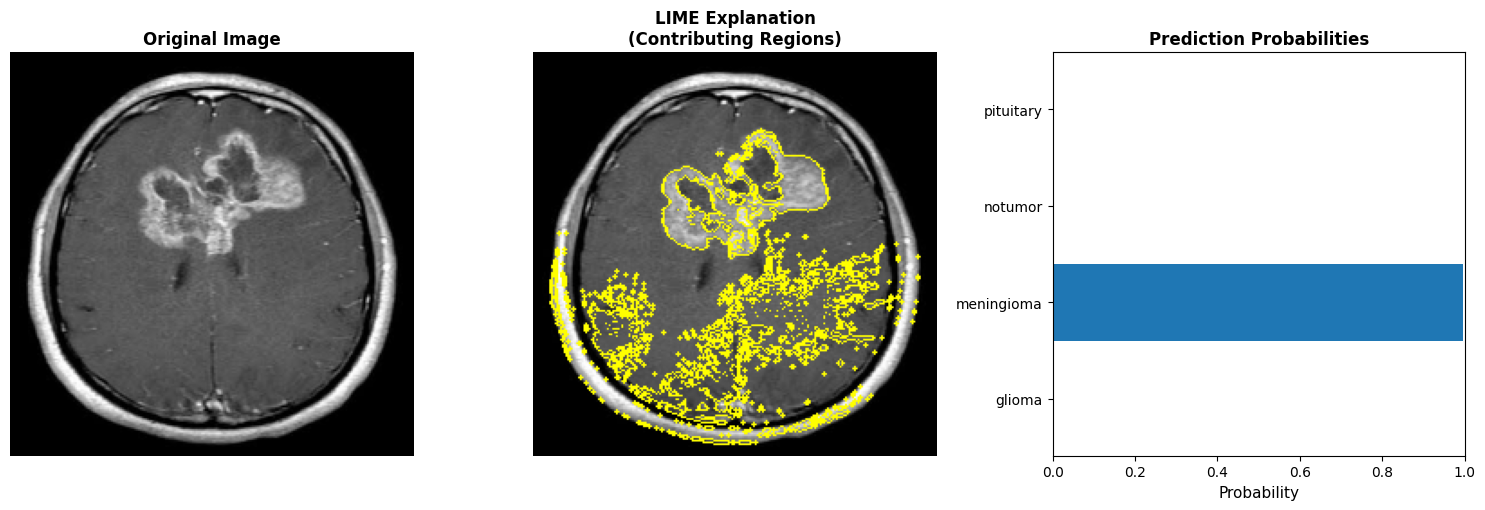

In [11]:
# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    """
    Prediction function for LIME explainer.
    """
    images = np.array(images, dtype=np.float32)
    images = preprocess_input(images.copy())
    return model.predict(images, verbose=0)

# Select a sample image for explanation
sample_idx = 0
test_image_path = test_df.iloc[sample_idx]['filepath']
sample_img = cv2.imread(test_image_path)

if sample_img is not None:
    if len(sample_img.shape) == 2:
        sample_img = cv2.cvtColor(sample_img, cv2.COLOR_GRAY2RGB)
    else:
        sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
    
    sample_img = cv2.resize(sample_img, (IMG_SIZE_DL, IMG_SIZE_DL))
    
    # Get prediction for this sample
    sample_pred_prob = model.predict(np.expand_dims(preprocess_input(sample_img.astype('float32')), axis=0), verbose=0)[0]
    sample_pred_class = np.argmax(sample_pred_prob)
    true_class = y_test[sample_idx]
    
    print(f"Image Index: {sample_idx}")
    print(f"True Class: {le.classes_[true_class]}")
    print(f"Predicted Class: {le.classes_[sample_pred_class]}")
    print(f"Prediction Confidence: {sample_pred_prob[sample_pred_class]:.4f}")
    print(f"\nGenerating LIME explanation (this may take a moment)...")
    
    # Generate LIME explanation
    explanation = explainer.explain_instance(
        sample_img.astype('double'),
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=500  # Reduced for speed
    )
    
    # Display explanation
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(sample_img)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # LIME explanation
    axes[1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1].set_title('LIME Explanation\n(Contributing Regions)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Prediction probabilities
    axes[2].barh(le.classes_, sample_pred_prob)
    axes[2].set_xlabel('Probability', fontsize=11)
    axes[2].set_title('Prediction Probabilities', fontsize=12, fontweight='bold')
    axes[2].set_xlim([0, 1])
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Error loading image: {test_image_path}")

## 12. Summary and Recommendations

In [12]:
print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"\n📋 Dataset Statistics:")
print(f"   • Training samples: {len(train_df)}")
print(f"   • Testing samples: {len(test_df)}")
print(f"   • Number of classes: {len(CLASSES)}")
print(f"   • Classes: {', '.join(CLASSES)}")

print(f"\n🧠 Model Architecture:")
print(f"   • Base Model: ResNet50 (pre-trained on ImageNet)")
print(f"   • Transfer Learning: Yes (frozen base layers)")
print(f"   • Custom Layers: Dense(512) -> Dense(256) -> Dense(4)")
print(f"   • Regularization: Dropout, Batch Normalization")

print(f"\n🎯 Performance Metrics:")
print(f"   • Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   • Test Precision: {test_precision:.4f}")
print(f"   • Test Recall: {test_recall:.4f}")
print(f"   • Test F1-Score: {test_f1:.4f}")
print(f"   • Training Time: {training_time:.2f} seconds")

print(f"\n🔒 Trustworthiness Score: {trustworthiness['overall_trustworthiness_score']:.2f}/100")

print(f"\n💡 Recommendations for Improvement:")
print(f"   1. Fine-tune the base ResNet50 model (unfreeze later layers)")
print(f"   2. Apply data augmentation (rotation, zoom, horizontal flip)")
print(f"   3. Use class weights to handle imbalanced data")
print(f"   4. Increase training epochs if model is underfitting")
print(f"   5. Implement cross-validation for more robust evaluation")
print(f"   6. Use ensemble methods (combine multiple models)")
print(f"   7. Collect more training data, especially for underperforming classes")
print(f"   8. Regular validation on real-world test cases")

print(f"\n" + "="*70)


PROJECT SUMMARY

📋 Dataset Statistics:
   • Training samples: 5600
   • Testing samples: 1600
   • Number of classes: 4
   • Classes: glioma, meningioma, notumor, pituitary

🧠 Model Architecture:
   • Base Model: ResNet50 (pre-trained on ImageNet)
   • Transfer Learning: Yes (frozen base layers)
   • Custom Layers: Dense(512) -> Dense(256) -> Dense(4)
   • Regularization: Dropout, Batch Normalization

🎯 Performance Metrics:
   • Test Accuracy: 0.5869 (58.69%)
   • Test Precision: 0.5258
   • Test Recall: 0.5869
   • Test F1-Score: 0.4936
   • Training Time: 5942.30 seconds

🔒 Trustworthiness Score: 58.16/100

💡 Recommendations for Improvement:
   1. Fine-tune the base ResNet50 model (unfreeze later layers)
   2. Apply data augmentation (rotation, zoom, horizontal flip)
   3. Use class weights to handle imbalanced data
   4. Increase training epochs if model is underfitting
   5. Implement cross-validation for more robust evaluation
   6. Use ensemble methods (combine multiple models)


## 13. Save the Model

In [13]:
# Save the trained model
model_save_path = 'brain_tumor_classifier_resnet50.h5'
model.save(model_save_path)
print(f"✅ Model saved to: {model_save_path}")

# Save the label encoder
import pickle
le_save_path = 'label_encoder.pkl'
with open(le_save_path, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ Label encoder saved to: {le_save_path}")

✅ Model saved to: brain_tumor_classifier_resnet50.h5
✅ Label encoder saved to: label_encoder.pkl
